In [1]:
import pandas as pd

file_path = "/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/final_geometry.csv"

df = pd.read_csv(file_path)

In [2]:
df_real = df[df["Synthetic"] == False]
df_syn  = df[df["Synthetic"] == True]

# 1. Distribution Comparison

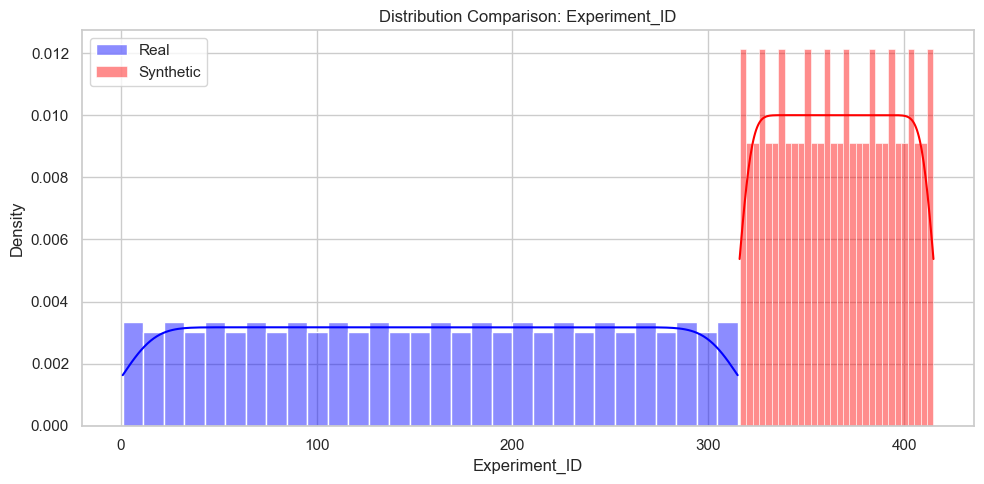

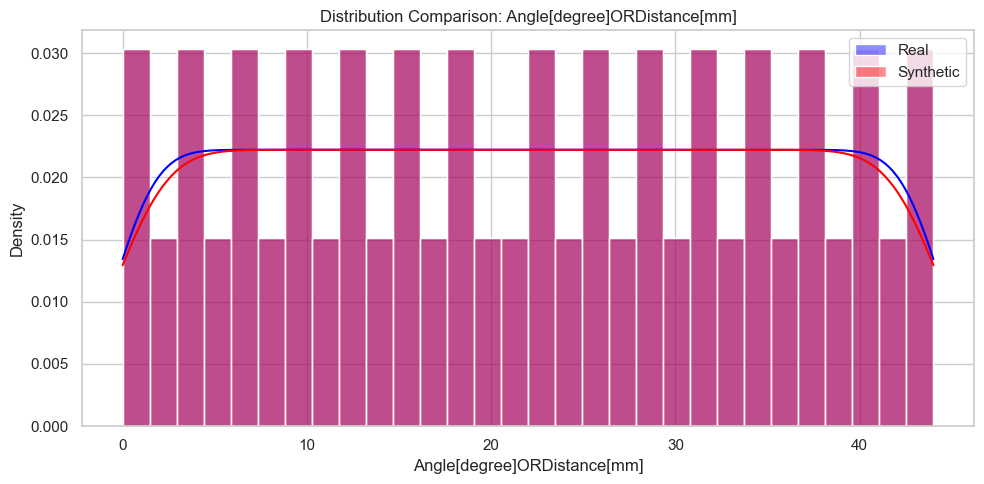

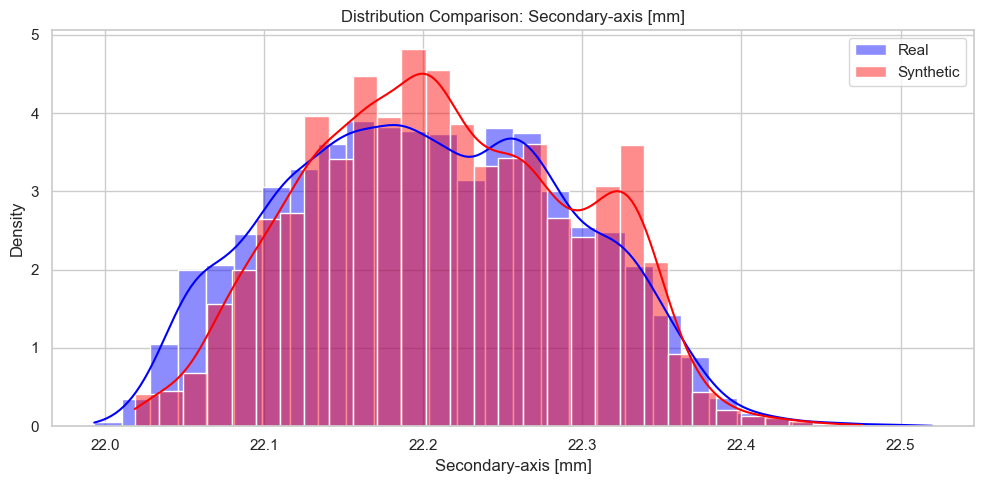

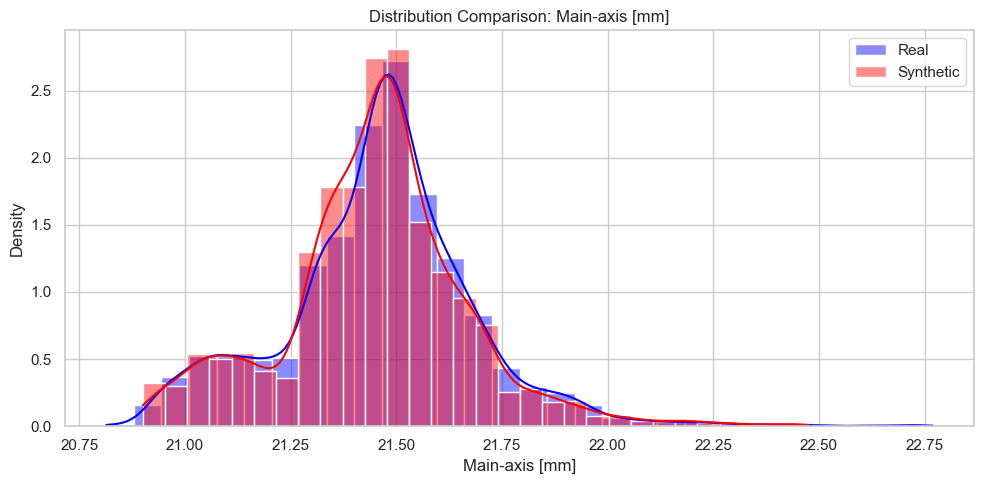

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
df_real = df[df["Synthetic"] == False].copy()
df_syn  = df[df["Synthetic"] == True].copy()

# Numerical columns only (exclude Synthetic)
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Remove Synthetic if encoded numeric
if "Synthetic" in num_cols:
    num_cols.remove("Synthetic")

# Style
sns.set(style="whitegrid")

# Plot histogram + KDE for each numeric column
for col in num_cols:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        df_real[col],
        color="blue",
        label="Real",
        stat="density",
        kde=True,
        bins=30,
        alpha=0.45
    )

    sns.histplot(
        df_syn[col],
        color="red",
        label="Synthetic",
        stat="density",
        kde=True,
        bins=30,
        alpha=0.45
    )

    plt.title(f"Distribution Comparison: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2. t-SNE Embedding Visualization

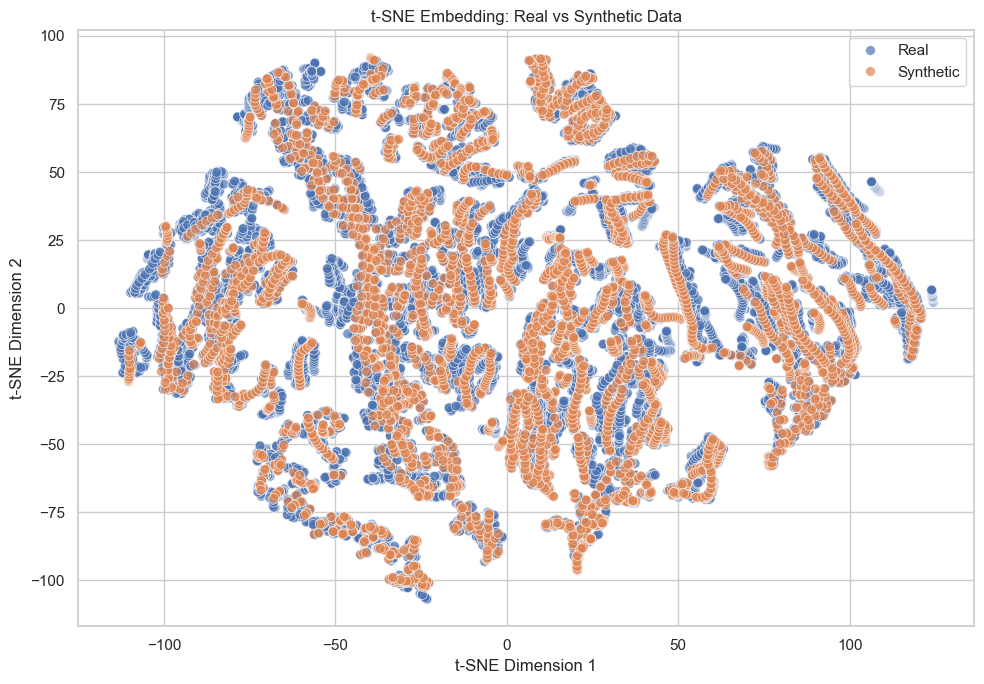

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# -------------------------------------------------
# Split data
# -------------------------------------------------
df_real = df[df["Synthetic"] == False].copy()
df_syn  = df[df["Synthetic"] == True].copy()

# -------------------------------------------------
# Prepare numeric features
# -------------------------------------------------
feature_df = df.select_dtypes(include=["number"]).copy()

# Remove target flag if numeric
if "Synthetic" in feature_df.columns:
    feature_df = feature_df.drop(columns=["Synthetic"])

# Optional: remove ID column if present
if "Experiment_ID" in feature_df.columns:
    feature_df = feature_df.drop(columns=["Experiment_ID"])

# Fill missing values
feature_df = feature_df.fillna(feature_df.median())

# -------------------------------------------------
# Standardize
# -------------------------------------------------
X_scaled = StandardScaler().fit_transform(feature_df)

# -------------------------------------------------
# t-SNE
# -------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# -------------------------------------------------
# Build result dataframe
# -------------------------------------------------
plot_df = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "Type": np.where(df["Synthetic"], "Synthetic", "Real")
})

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="TSNE_1",
    y="TSNE_2",
    hue="Type",
    alpha=0.7,
    s=50
)

plt.title("t-SNE Embedding: Real vs Synthetic Data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="")
plt.tight_layout()
plt.show()

# 3. Confusion Matrix

Accuracy: 0.7348

              precision    recall  f1-score   support

        Real       0.77      0.92      0.84      3544
   Synthetic       0.38      0.15      0.22      1125

    accuracy                           0.73      4669
   macro avg       0.58      0.54      0.53      4669
weighted avg       0.68      0.73      0.69      4669



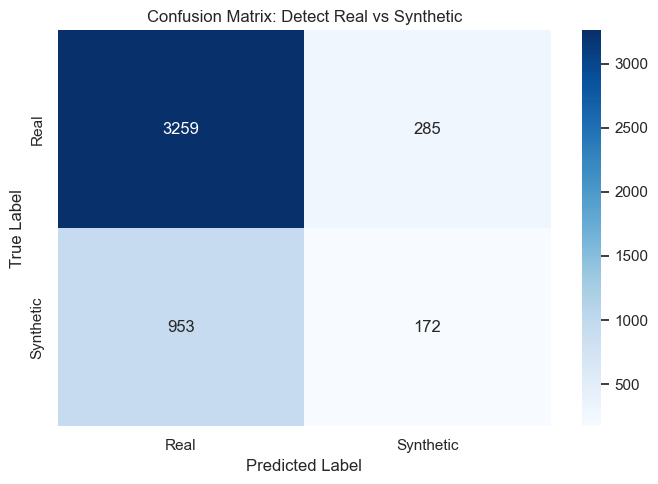

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# -------------------------------------------------
# Prepare data
# -------------------------------------------------
df_model = df.copy()

# Convert target to int
y = df_model["Synthetic"].astype(int)

# Keep numeric features only
X = df_model.select_dtypes(include=["number"]).copy()

# Remove target if numeric
if "Synthetic" in X.columns:
    X = X.drop(columns=["Synthetic"])

# Optional: remove ID column
if "Experiment_ID" in X.columns:
    X = X.drop(columns=["Experiment_ID"])

# Fill missing values
X = X.fillna(X.median())

# -------------------------------------------------
# Train / Test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# -------------------------------------------------
# Train classifier
# -------------------------------------------------
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

# -------------------------------------------------
# Predict
# -------------------------------------------------
y_pred = clf.predict(X_test)

# -------------------------------------------------
# Metrics
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Real", "Synthetic"]))

# -------------------------------------------------
# Plot confusion matrix
# -------------------------------------------------
plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Synthetic"],
    yticklabels=["Real", "Synthetic"]
)

plt.title("Confusion Matrix: Detect Real vs Synthetic")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 4. Training Curves

/Users/soroureskandari/Master Thesis /tube-bending-geometry/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/soroureskandari/Master Thesis /tube-bending-geometry/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/soroureskandari/Master Thesis /tube-bending-geometry/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/soroureskandari/Master Thesis /tube-bending-geometry/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Convergen

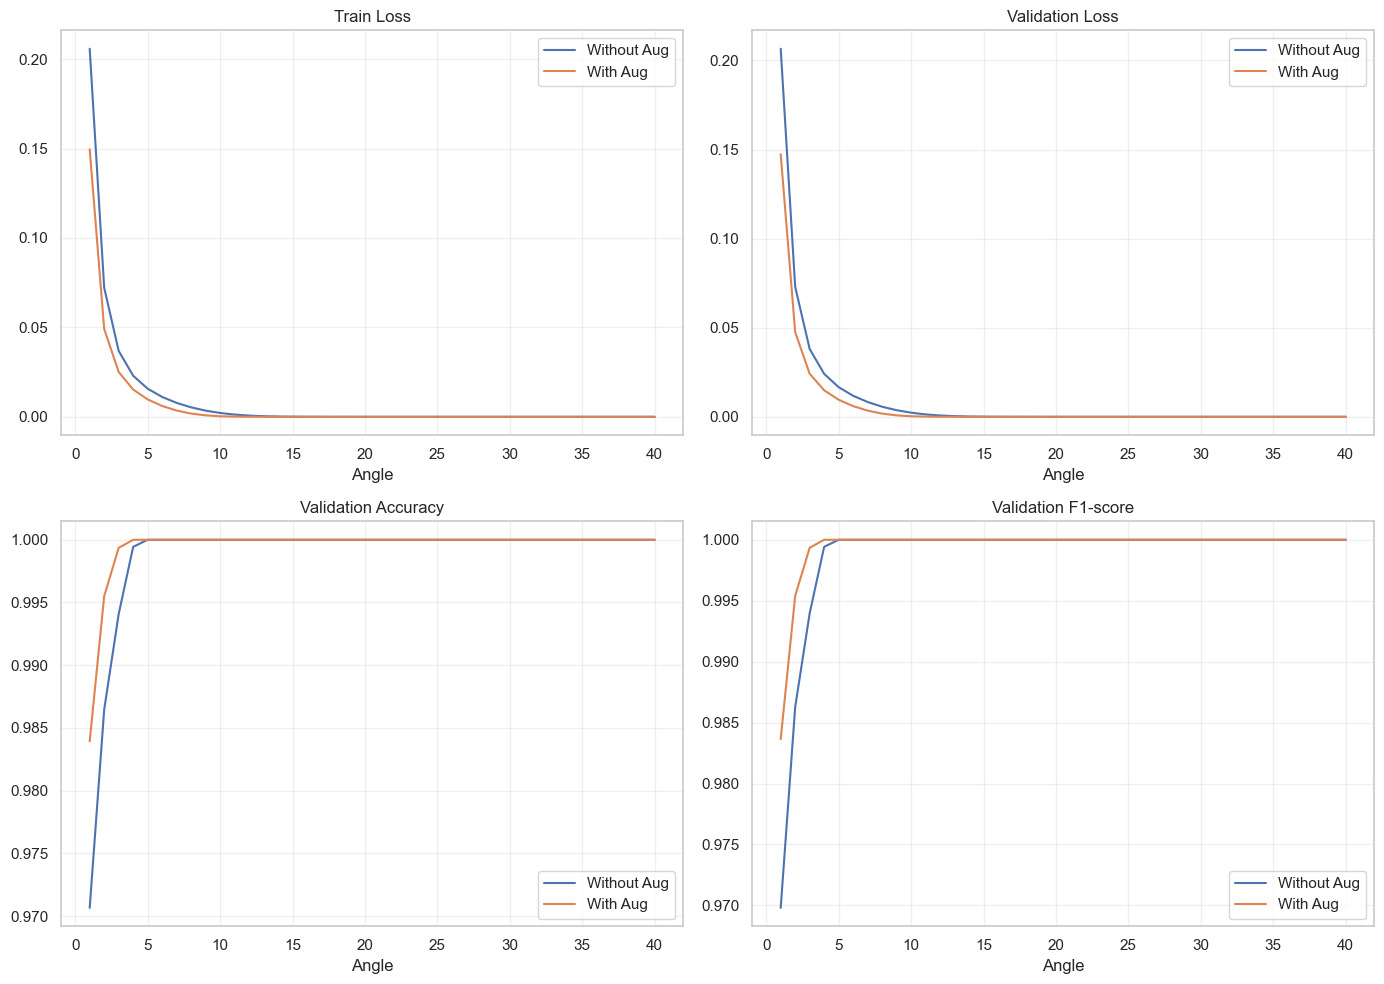

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score, f1_score

# =========================================================
# CONFIG
# =========================================================
EPOCHS = 40
TEST_SIZE = 0.25
RANDOM_STATE = 42

# =========================================================
# PREPARE DATA
# =========================================================
df_real = df[df["Synthetic"] == False].copy()
df_syn  = df[df["Synthetic"] == True].copy()

# Use numeric columns only
feature_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Remove labels / IDs
drop_cols = []
if "Synthetic" in feature_cols:
    drop_cols.append("Synthetic")
if "Experiment_ID" in feature_cols:
    drop_cols.append("Experiment_ID")

feature_cols = [c for c in feature_cols if c not in drop_cols]

# -------------------------------
# REAL-ONLY dataset
# -------------------------------
real_binary = df_real.copy()
real_binary["target"] = 0

# Duplicate target classes inside real data example:
# split by median to create a supervised benchmark
median_val = real_binary[feature_cols[0]].median()
real_binary["target"] = (real_binary[feature_cols[0]] > median_val).astype(int)

# -------------------------------
# AUGMENTED dataset
# Use real + synthetic
# Same target rule
# -------------------------------
aug_df = pd.concat([df_real, df_syn], axis=0).reset_index(drop=True)
median_val2 = aug_df[feature_cols[0]].median()
aug_df["target"] = (aug_df[feature_cols[0]] > median_val2).astype(int)

# =========================================================
# FUNCTION
# =========================================================
def run_training_curve(dataframe, feature_cols, label_col="target"):
    
    X = dataframe[feature_cols].fillna(dataframe[feature_cols].median())
    y = dataframe[label_col]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=1,
        warm_start=True,
        random_state=RANDOM_STATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy": [],
        "f1": []
    }

    classes = np.unique(y)

    for epoch in range(EPOCHS):
        model.fit(X_train, y_train)

        train_prob = model.predict_proba(X_train)
        val_prob   = model.predict_proba(X_val)

        val_pred = model.predict(X_val)

        history["train_loss"].append(log_loss(y_train, train_prob))
        history["val_loss"].append(log_loss(y_val, val_prob))
        history["accuracy"].append(accuracy_score(y_val, val_pred))
        history["f1"].append(f1_score(y_val, val_pred))

    return history

# =========================================================
# RUN BOTH
# =========================================================
hist_no_aug = run_training_curve(real_binary, feature_cols)
hist_aug    = run_training_curve(aug_df, feature_cols)

# =========================================================
# PLOT
# =========================================================
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Train loss
axes[0,0].plot(epochs, hist_no_aug["train_loss"], label="Without Aug")
axes[0,0].plot(epochs, hist_aug["train_loss"], label="With Aug")
axes[0,0].set_title("Train Loss")
axes[0,0].legend()

# Validation loss
axes[0,1].plot(epochs, hist_no_aug["val_loss"], label="Without Aug")
axes[0,1].plot(epochs, hist_aug["val_loss"], label="With Aug")
axes[0,1].set_title("Validation Loss")
axes[0,1].legend()

# Accuracy
axes[1,0].plot(epochs, hist_no_aug["accuracy"], label="Without Aug")
axes[1,0].plot(epochs, hist_aug["accuracy"], label="With Aug")
axes[1,0].set_title("Validation Accuracy")
axes[1,0].legend()

# F1-score
axes[1,1].plot(epochs, hist_no_aug["f1"], label="Without Aug")
axes[1,1].plot(epochs, hist_aug["f1"], label="With Aug")
axes[1,1].set_title("Validation F1-score")
axes[1,1].legend()

for ax in axes.flat:
    ax.set_xlabel("Angle")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Precision / Recall / ROC Curves

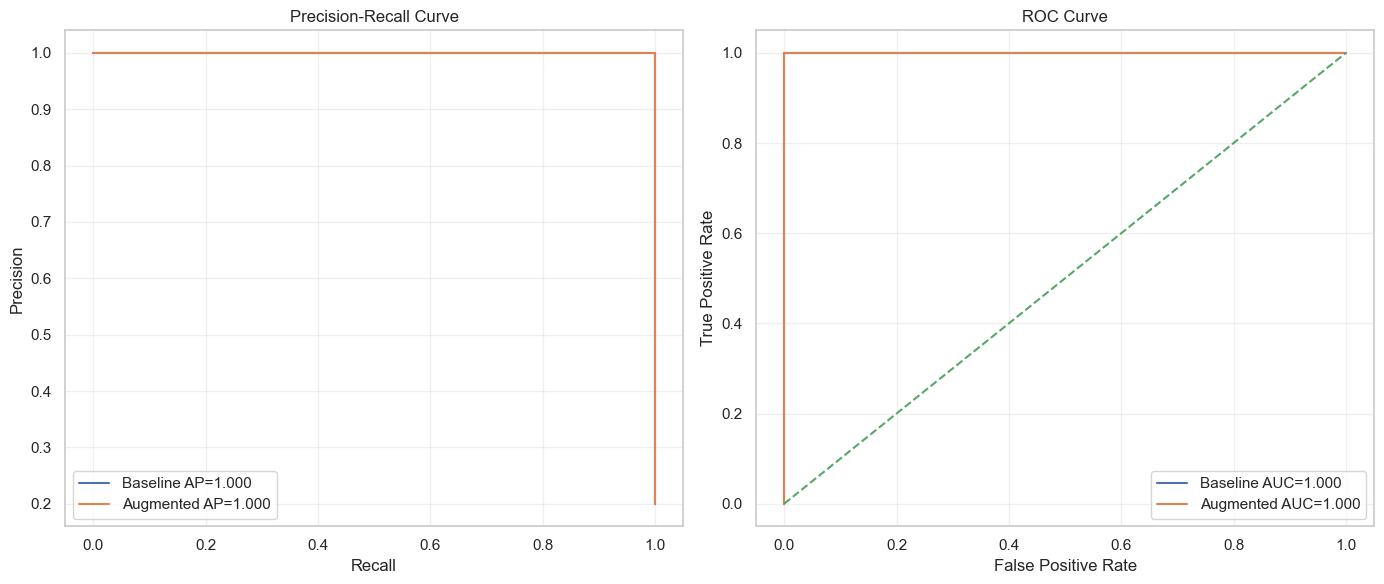

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle

# =========================================================
# DATA PREP
# =========================================================
df_real = df[df["Synthetic"] == False].copy()
df_syn  = df[df["Synthetic"] == True].copy()

# Numeric features only
feature_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Remove non-feature columns
drop_cols = []
if "Synthetic" in feature_cols:
    drop_cols.append("Synthetic")
if "Experiment_ID" in feature_cols:
    drop_cols.append("Experiment_ID")

feature_cols = [c for c in feature_cols if c not in drop_cols]

# =========================================================
# CREATE IMBALANCED CLASSIFICATION TASK
# (replace with your real target if available)
# =========================================================
# Example target = top 20% of first feature
threshold = df_real[feature_cols[0]].quantile(0.80)

df_real["target"] = (df_real[feature_cols[0]] >= threshold).astype(int)
df_syn["target"]  = (df_syn[feature_cols[0]] >= threshold).astype(int)

# =========================================================
# BASELINE DATASET (REAL ONLY)
# =========================================================
base_df = df_real.copy()

X_base = base_df[feature_cols].fillna(base_df[feature_cols].median())
y_base = base_df["target"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base,
    test_size=0.25,
    stratify=y_base,
    random_state=42
)

# =========================================================
# AUGMENTED DATASET
# Add synthetic only to train set
# =========================================================
X_real = df_real[feature_cols].fillna(df_real[feature_cols].median())
y_real = df_real["target"]

Xa_train_real, Xa_test, ya_train_real, ya_test = train_test_split(
    X_real, y_real,
    test_size=0.25,
    stratify=y_real,
    random_state=42
)

X_syn = df_syn[feature_cols].fillna(df_syn[feature_cols].median())
y_syn = df_syn["target"]

Xa_train = pd.concat([Xa_train_real, X_syn], axis=0)
ya_train = pd.concat([ya_train_real, y_syn], axis=0)

Xa_train, ya_train = shuffle(Xa_train, ya_train, random_state=42)

# =========================================================
# TRAIN MODELS
# =========================================================
baseline_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

aug_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(Xb_train, yb_train)
aug_model.fit(Xa_train, ya_train)

# =========================================================
# PREDICT PROBABILITIES
# =========================================================
base_probs = baseline_model.predict_proba(Xb_test)[:, 1]
aug_probs  = aug_model.predict_proba(Xa_test)[:, 1]

# =========================================================
# PRECISION-RECALL
# =========================================================
p_base, r_base, _ = precision_recall_curve(yb_test, base_probs)
p_aug, r_aug, _   = precision_recall_curve(ya_test, aug_probs)

ap_base = average_precision_score(yb_test, base_probs)
ap_aug  = average_precision_score(ya_test, aug_probs)

# =========================================================
# ROC
# =========================================================
fpr_base, tpr_base, _ = roc_curve(yb_test, base_probs)
fpr_aug, tpr_aug, _   = roc_curve(ya_test, aug_probs)

roc_auc_base = auc(fpr_base, tpr_base)
roc_auc_aug  = auc(fpr_aug, tpr_aug)

# =========================================================
# PLOTS
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Precision Recall
axes[0].plot(r_base, p_base, label=f"Baseline AP={ap_base:.3f}")
axes[0].plot(r_aug, p_aug, label=f"Augmented AP={ap_aug:.3f}")
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC
axes[1].plot(fpr_base, tpr_base, label=f"Baseline AUC={roc_auc_base:.3f}")
axes[1].plot(fpr_aug, tpr_aug, label=f"Augmented AUC={roc_auc_aug:.3f}")
axes[1].plot([0,1], [0,1], linestyle="--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Real vs Fake Trend

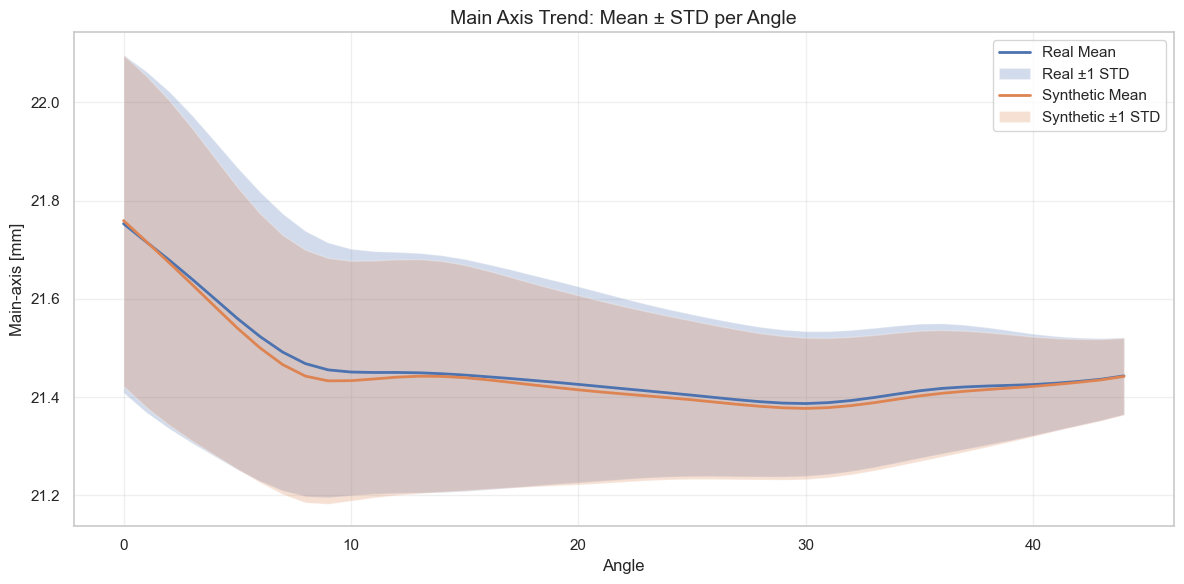

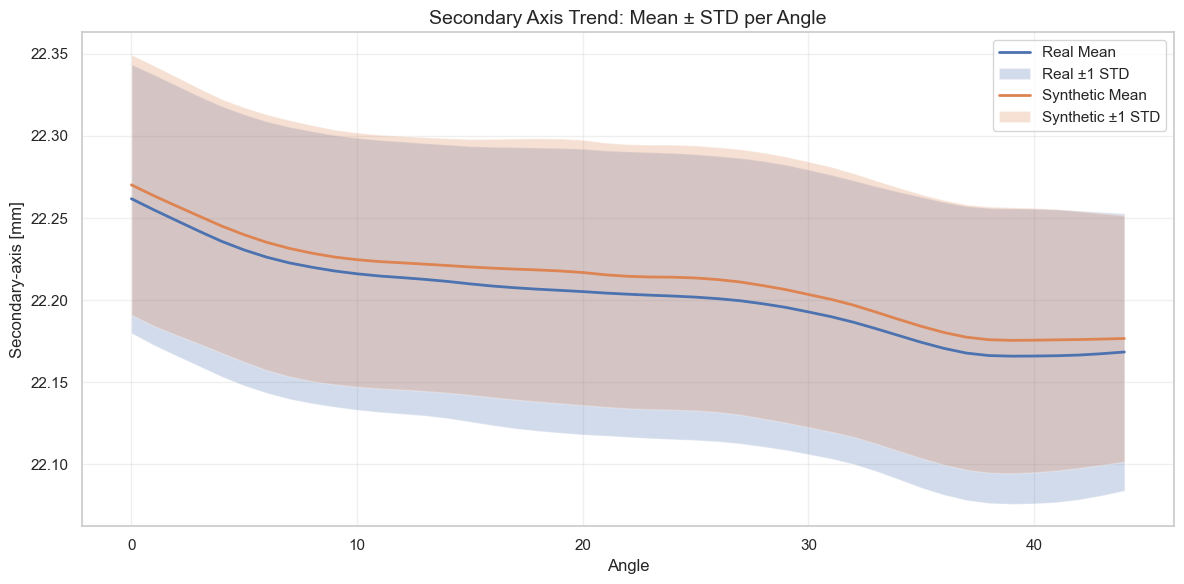

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SPLIT DATA
# ==========================================================
df_real = df[df["Synthetic"] == False].copy()
df_fake = df[df["Synthetic"] == True].copy()

# ==========================================================
# COLUMN NAMES
# Adjust if needed
# ==========================================================
angle_col = "Angle[degree]ORDistance[mm]"
main_col = "Main-axis [mm]"
sec_col = "Secondary-axis [mm]"

# Ensure sorted angle
df_real[angle_col] = pd.to_numeric(df_real[angle_col], errors="coerce")
df_fake[angle_col] = pd.to_numeric(df_fake[angle_col], errors="coerce")

# ==========================================================
# FUNCTION TO PLOT MEAN ± STD
# ==========================================================
def plot_mean_std(real_df, fake_df, value_col, title):
    
    # Aggregate real
    real_stats = (
        real_df.groupby(angle_col)[value_col]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(angle_col)
    )
    
    # Aggregate fake
    fake_stats = (
        fake_df.groupby(angle_col)[value_col]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(angle_col)
    )

    plt.figure(figsize=(12,6))

    # ---------------- REAL ----------------
    plt.plot(
        real_stats[angle_col],
        real_stats["mean"],
        label="Real Mean",
        linewidth=2
    )

    plt.fill_between(
        real_stats[angle_col],
        real_stats["mean"] - real_stats["std"],
        real_stats["mean"] + real_stats["std"],
        alpha=0.25,
        label="Real ±1 STD"
    )

    # ---------------- FAKE ----------------
    plt.plot(
        fake_stats[angle_col],
        fake_stats["mean"],
        label="Synthetic Mean",
        linewidth=2
    )

    plt.fill_between(
        fake_stats[angle_col],
        fake_stats["mean"] - fake_stats["std"],
        fake_stats["mean"] + fake_stats["std"],
        alpha=0.25,
        label="Synthetic ±1 STD"
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Angle")
    plt.ylabel(value_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================================
# PLOT MAIN
# ==========================================================
plot_mean_std(
    df_real,
    df_fake,
    main_col,
    "Main Axis Trend: Mean ± STD per Angle"
)

# ==========================================================
# PLOT SECONDARY
# ==========================================================
plot_mean_std(
    df_real,
    df_fake,
    sec_col,
    "Secondary Axis Trend: Mean ± STD per Angle"
)

# 7. Experiment-wise Comparison

Random Real IDs : [ 51 263 174 195 252]
Random Fake IDs : [335 322 395 391 339]


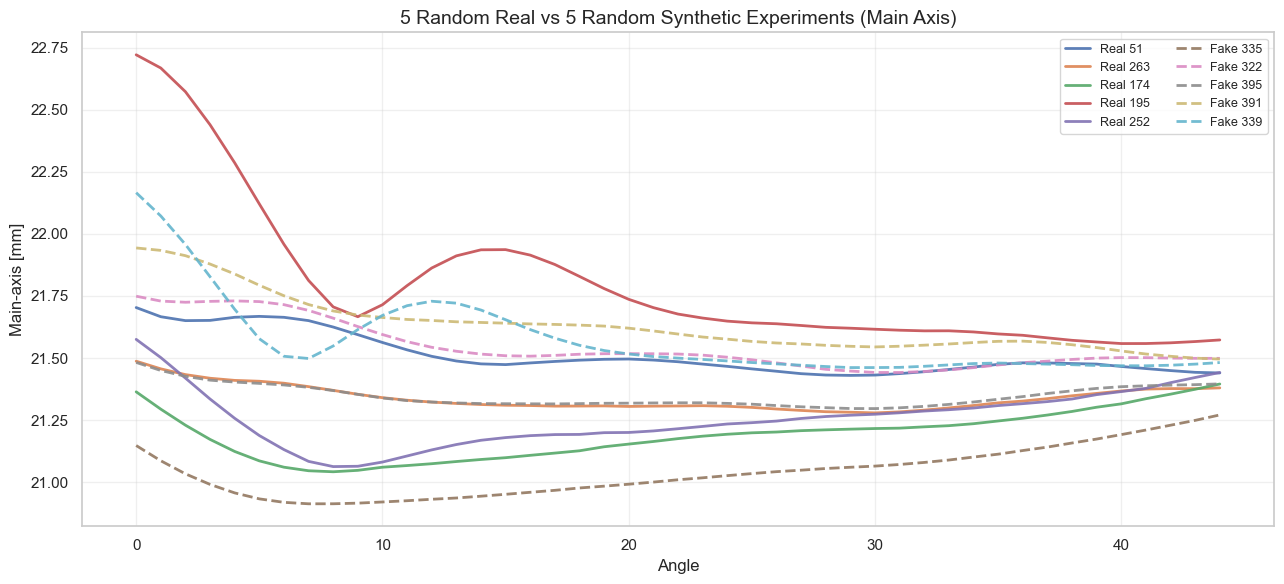

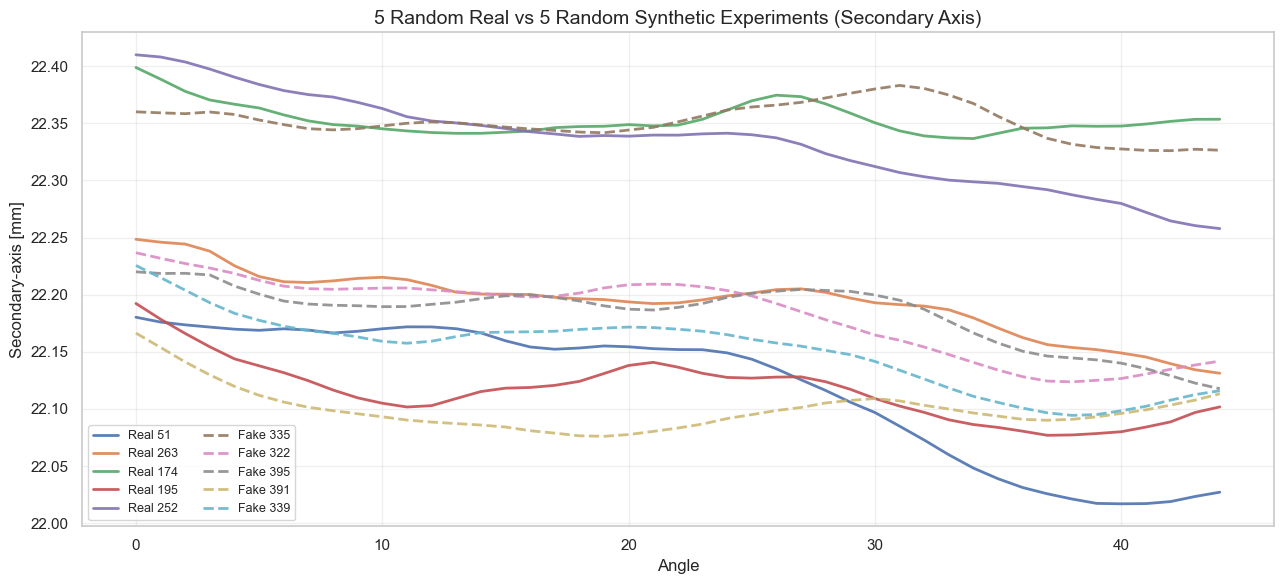

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SPLIT DATA
# ==========================================================
df_real = df[df["Synthetic"] == False].copy()
df_fake = df[df["Synthetic"] == True].copy()

# ==========================================================
# COLUMN NAMES
# ==========================================================
angle_col = "Angle[degree]ORDistance[mm]"
main_col  = "Main-axis [mm]"
sec_col   = "Secondary-axis [mm]"
id_col    = "Experiment_ID"

# ==========================================================
# NUMERIC ANGLE
# ==========================================================
df_real[angle_col] = pd.to_numeric(df_real[angle_col], errors="coerce")
df_fake[angle_col] = pd.to_numeric(df_fake[angle_col], errors="coerce")

# ==========================================================
# PICK NEW RANDOM IDs EACH RUN
# (no seed = different every run)
# ==========================================================
real_ids = np.random.choice(
    df_real[id_col].dropna().unique(),
    size=min(5, df_real[id_col].nunique()),
    replace=False
)

fake_ids = np.random.choice(
    df_fake[id_col].dropna().unique(),
    size=min(5, df_fake[id_col].nunique()),
    replace=False
)

print("Random Real IDs :", real_ids)
print("Random Fake IDs :", fake_ids)

# ==========================================================
# FUNCTION
# ==========================================================
def plot_random_curves(value_col, title):

    plt.figure(figsize=(13,6))

    # REAL
    for rid in real_ids:
        temp = df_real[df_real[id_col] == rid].sort_values(angle_col)

        plt.plot(
            temp[angle_col],
            temp[value_col],
            linewidth=2,
            alpha=0.9,
            label=f"Real {rid}"
        )

    # FAKE
    for fid in fake_ids:
        temp = df_fake[df_fake[id_col] == fid].sort_values(angle_col)

        plt.plot(
            temp[angle_col],
            temp[value_col],
            linestyle="--",
            linewidth=2,
            alpha=0.9,
            label=f"Fake {fid}"
        )

    plt.title(title, fontsize=14)
    plt.xlabel("Angle")
    plt.ylabel(value_col)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# ==========================================================
# MAIN
# ==========================================================
plot_random_curves(
    main_col,
    "5 Random Real vs 5 Random Synthetic Experiments (Main Axis)"
)

# ==========================================================
# SECONDARY
# ==========================================================
plot_random_curves(
    sec_col,
    "5 Random Real vs 5 Random Synthetic Experiments (Secondary Axis)"
)